# California Wildfires Bluesky Analysis

**Outputs:**
1. Overall TF-IDF wordcloud
2. Week-by-week wordcloud collage
3. Top words stream chart

In [50]:
# --- Imports and Config ---
import json
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud

# Paths
DATA_DIR = Path("../data/bluesky")
POSTS_PATH = DATA_DIR / "posts_all_clean.jsonl"
OUTPUT_DIR = Path("../figures/wordcloud_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

In [51]:
# --- Load Data ---
def read_jsonl(path):
    """Read JSONL file into DataFrame."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    continue
    return pd.json_normalize(records)

posts = read_jsonl(POSTS_PATH)
posts["created_at"] = pd.to_datetime(posts["created_at"], errors="coerce", utc=True)
posts = posts.dropna(subset=["text"])
posts["text"] = posts["text"].astype(str)

print(f"Loaded {len(posts):,} posts")
print(f"Date range: {posts['created_at'].min()} to {posts['created_at'].max()}")

Loaded 8,834 posts
Date range: 2025-01-01 13:12:16.250000+00:00 to 2025-02-07 23:57:52.700000+00:00


In [52]:
# --- Text Preprocessing ---
URL_RE = re.compile(r"http[s]?://\S+")
MENTION_RE = re.compile(r"@[A-Za-z0-9_.-]+")
HASHTAG_RE = re.compile(r"#[A-Za-z0-9_]+")

def clean_text(text):
    """Remove URLs, mentions, hashtags, and non-alpha chars."""
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(" ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

posts["clean_text"] = posts["text"].map(clean_text)
posts = posts[posts["clean_text"].str.len() > 0]
posts["date_only"] = posts["created_at"].dt.date

print(f"After cleaning: {len(posts):,} posts")

After cleaning: 8,792 posts


In [53]:
# --- TF-IDF Setup ---
DOMAIN_STOPWORDS = {
    "california", "wildfire", "wildfires", "fire", "fires", "los", "angeles",
    "bluesky", "bsky", "post", "posts", "click", "tap", "trending",
    "www", "http", "https", "com", "co", "amp",
    "like", "just", "really", "going", "got", "get", "know", "think",
    "want", "need", "see", "say", "said", "says", "make", "made",
    "way", "thing", "things", "time", "year", "years", "day", "days",
    "people", "new", "good", "right", "don", "didn", "doesn", "won",
    "isn", "aren", "wasn", "weren", "let", "ll", "ve", "re",
}

def compute_tfidf(texts, max_features=2000, min_df=2, max_df=0.8, ngram_range=(1, 1)):
    """Compute TF-IDF scores, return {term: score} dict."""
    stopwords = list(ENGLISH_STOP_WORDS.union(DOMAIN_STOPWORDS))
    vectorizer = TfidfVectorizer(
        max_features=max_features, min_df=min_df, max_df=max_df,
        ngram_range=ngram_range, stop_words=stopwords,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b",
    )
    try:
        X = vectorizer.fit_transform(texts)
        if X.shape[0] == 0 or X.shape[1] == 0:
            return {}
        scores = np.asarray(X.mean(axis=0)).ravel()
        return dict(zip(vectorizer.get_feature_names_out(), scores))
    except ValueError:
        return {}

def make_wordcloud(scores, title="", max_words=150, width=800, height=500, ax=None):
    """Generate wordcloud from TF-IDF scores."""
    if not scores:
        return None
    
    merged = {k.strip().lower(): max(v, scores.get(k, 0)) for k, v in scores.items() if isinstance(k, str)}
    wc = WordCloud(
        width=width, height=height, background_color="white",
        max_words=max_words, colormap="viridis", repeat=False,
    ).generate_from_frequencies(merged)
    
    if ax is None:
        plt.figure(figsize=(10, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title, fontsize=14, fontweight="bold")
        plt.tight_layout()
    else:
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(title, fontsize=11, fontweight="bold")
    return wc

## 1. Overall Wordcloud

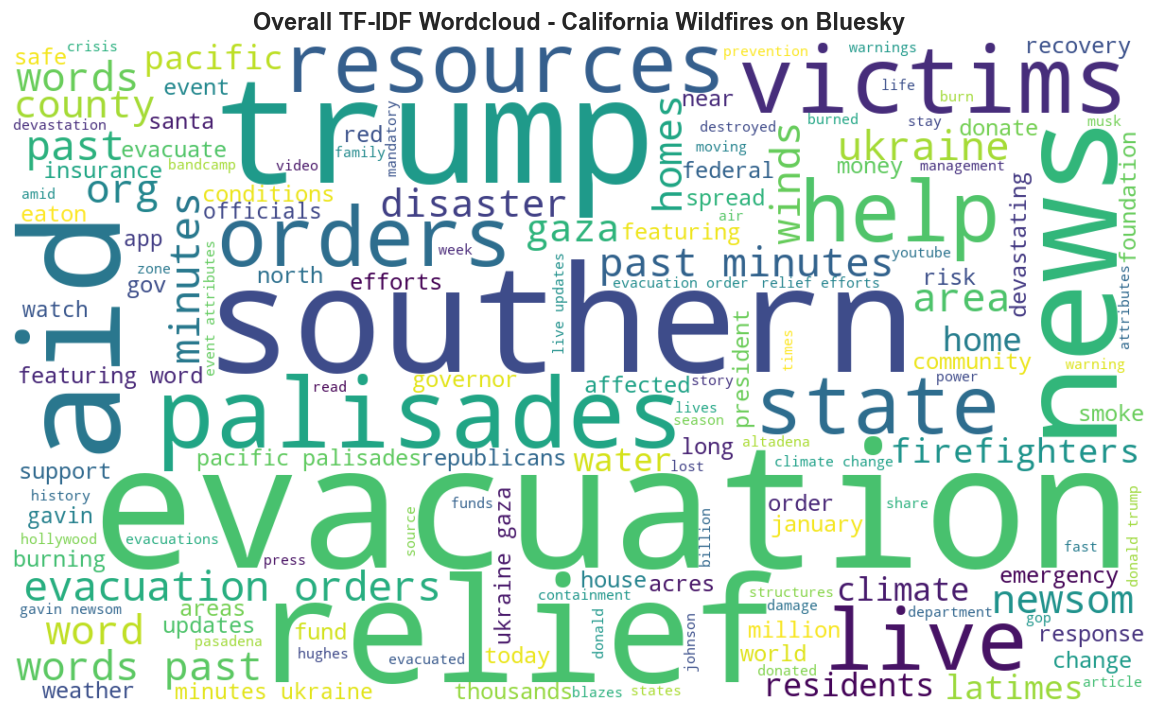

Top 20 terms: [('evacuation', np.float64(0.024056312942863894)), ('southern', np.float64(0.017160088822784494)), ('trump', np.float64(0.01694624016628571)), ('relief', np.float64(0.016554879066744847)), ('aid', np.float64(0.014754704411740295)), ('news', np.float64(0.01466425418526112)), ('palisades', np.float64(0.014347300400876756)), ('victims', np.float64(0.012829709794376693)), ('live', np.float64(0.010839808994673425)), ('help', np.float64(0.010647179819676061)), ('resources', np.float64(0.010254200940688562)), ('orders', np.float64(0.010250271138143524)), ('state', np.float64(0.010021610234161319)), ('evacuation orders', np.float64(0.009915674054373068)), ('past', np.float64(0.00984408923873011)), ('minutes', np.float64(0.009696202709765813)), ('words', np.float64(0.009353939757488992)), ('word', np.float64(0.009263358931745796)), ('area', np.float64(0.00924804487116254)), ('winds', np.float64(0.009142929157036477))]


In [54]:
# Compute and plot overall wordcloud
overall_scores = compute_tfidf(posts["clean_text"].tolist(), max_features=3000, min_df=2, max_df=0.9, ngram_range=(1, 2))

make_wordcloud(overall_scores, title="Overall TF-IDF Wordcloud - California Wildfires on Bluesky",
               max_words=150, width=1200, height=700)
plt.savefig(OUTPUT_DIR / "overall_wordcloud.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Top 20 terms: {sorted(overall_scores.items(), key=lambda x: x[1], reverse=True)[:20]}")

## 2. Weekly Wordcloud Collage

In [55]:
# Define time periods
periods = {
    "Jan 1-6": ("2025-01-01", "2025-01-06"),
    "Jan 7-13": ("2025-01-07", "2025-01-13"),
    "Jan 14-21": ("2025-01-14", "2025-01-21"),
    "Jan 22-31": ("2025-01-22", "2025-01-31"),
    "Feb 1-7": ("2025-02-01", "2025-02-07"),
}
periods = {k: (pd.to_datetime(v[0]).date(), pd.to_datetime(v[1]).date()) for k, v in periods.items()}

# Compute TF-IDF per period
period_scores, period_counts = {}, {}
for label, (start, end) in periods.items():
    mask = (posts["date_only"] >= start) & (posts["date_only"] <= end)
    group = posts[mask]
    period_counts[label] = len(group)
    period_scores[label] = compute_tfidf(group["clean_text"].tolist(), min_df=1, ngram_range=(1, 2)) if len(group) > 0 else {}
    print(f"{label}: {len(group):,} posts, {len(period_scores[label]):,} terms")

Jan 1-6: 60 posts, 1,173 terms
Jan 7-13: 4,570 posts, 2,000 terms
Jan 14-21: 1,737 posts, 2,000 terms
Jan 22-31: 1,351 posts, 2,000 terms
Feb 1-7: 355 posts, 2,000 terms


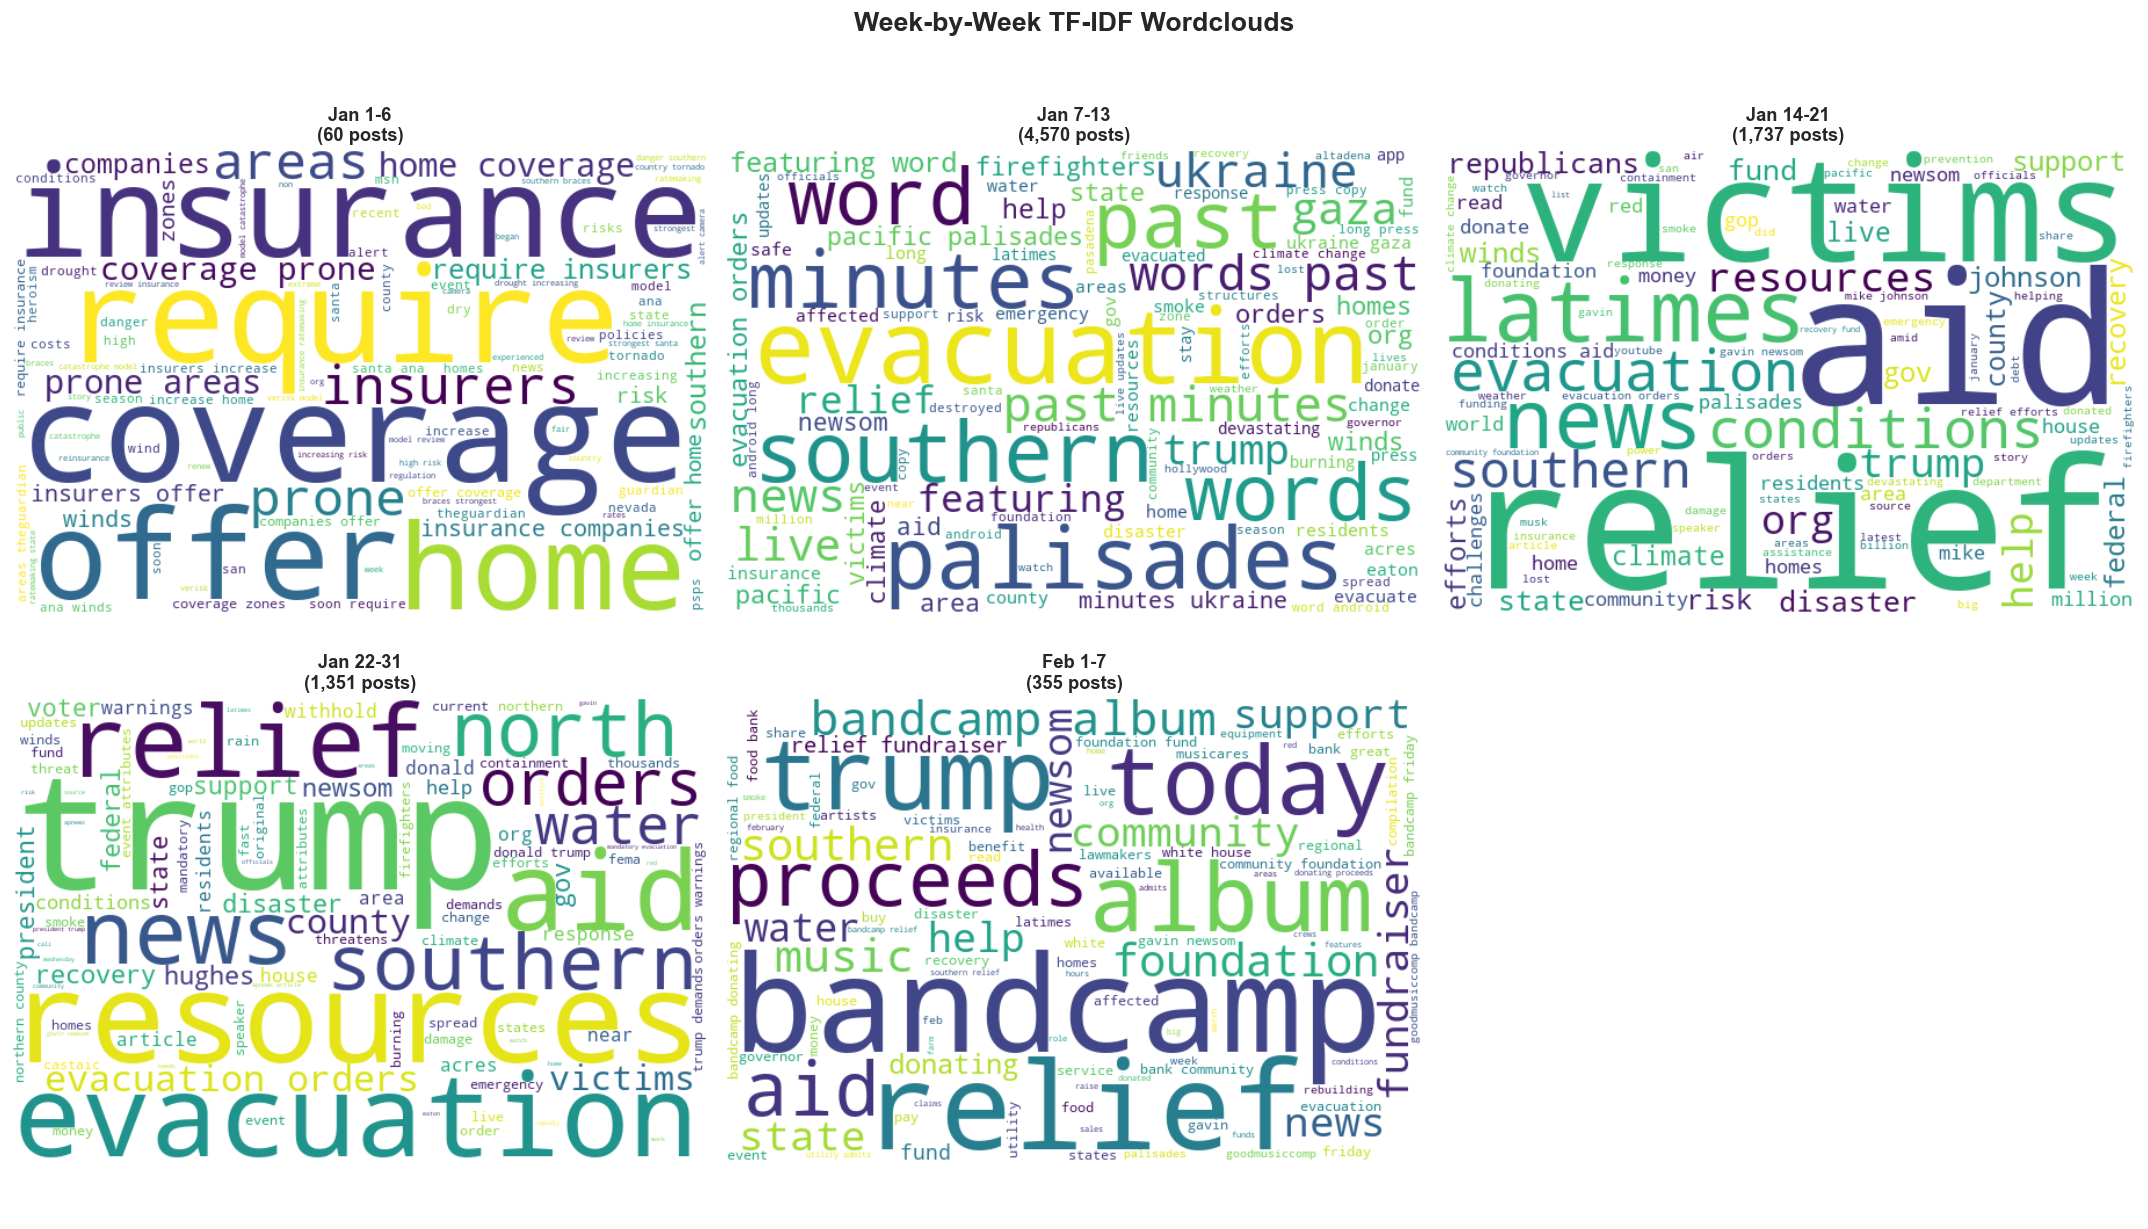

In [56]:
# Create 5-panel wordcloud collage
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, label in enumerate(periods.keys()):
    scores = period_scores.get(label, {})
    title = f"{label}\n({period_counts[label]:,} posts)"
    if scores:
        make_wordcloud(scores, title=title, max_words=100, width=600, height=400, ax=axes[idx])
    else:
        axes[idx].text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)
        axes[idx].set_title(title, fontsize=11, fontweight="bold")
        axes[idx].axis("off")

axes[5].axis("off")  # Hide 6th subplot

plt.suptitle("Week-by-Week TF-IDF Wordclouds", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weekly_wordcloud_collage.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 3. Top Words Stream Chart

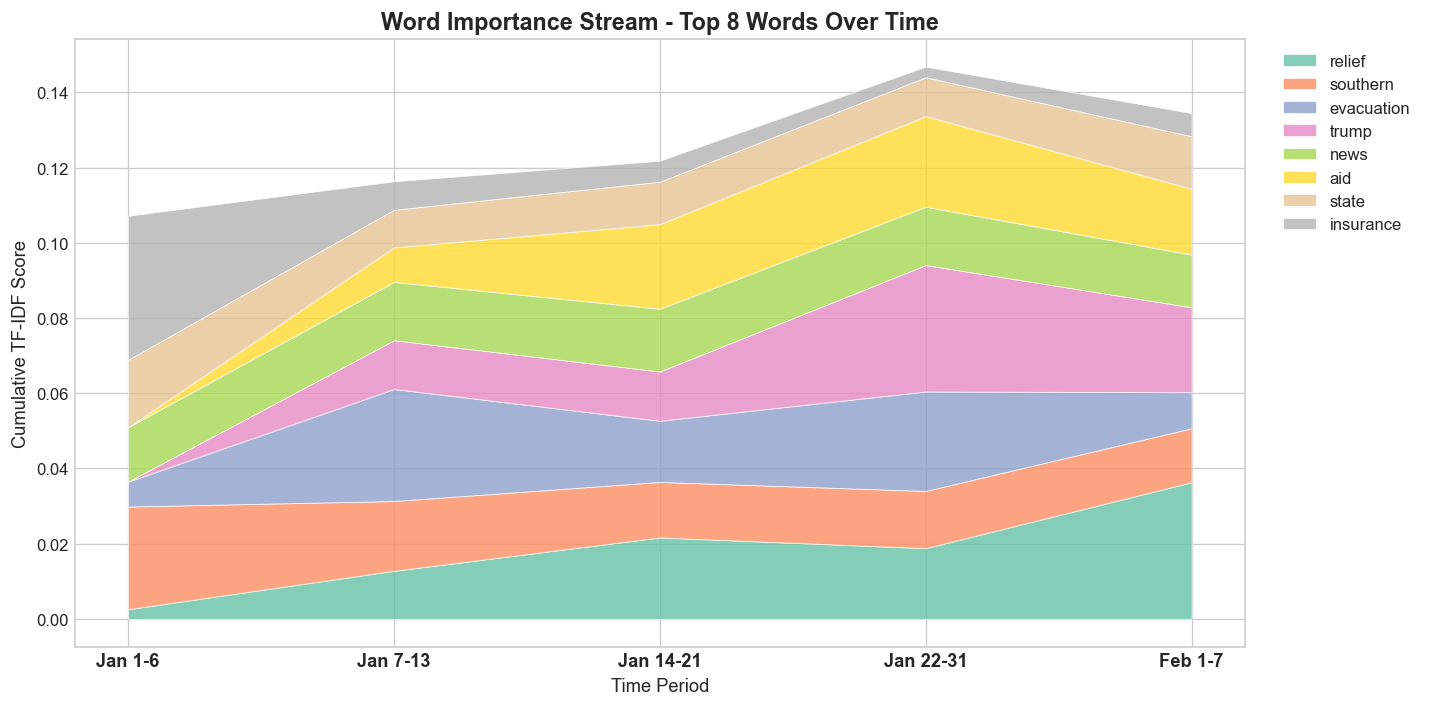

In [57]:
# Get top 8 words by total TF-IDF across all periods
all_top_words = set()
for scores in period_scores.values():
    all_top_words.update(sorted(scores.keys(), key=lambda x: scores[x], reverse=True)[:15])

word_totals = {w: sum(period_scores.get(l, {}).get(w, 0) for l in periods) for w in all_top_words}
top_8 = sorted(word_totals.keys(), key=lambda x: word_totals[x], reverse=True)[:8]

# Build stacked area data
area_data = {w: [period_scores.get(l, {}).get(w, 0) for l in periods] for w in top_8}

# Plot stream chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(periods))
colors = plt.cm.Set2(np.linspace(0, 1, len(top_8)))

bottom = np.zeros(len(periods))
for idx, word in enumerate(top_8):
    values = np.array(area_data[word])
    ax.fill_between(x, bottom, bottom + values, label=word, color=colors[idx], alpha=0.8, edgecolor='white', linewidth=0.5)
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(list(periods.keys()), fontsize=11, fontweight='bold')
ax.set_ylabel("Cumulative TF-IDF Score", fontsize=11)
ax.set_xlabel("Time Period", fontsize=11)
ax.set_title("Word Importance Stream - Top 8 Words Over Time", fontsize=14, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_words_stream.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [58]:
# --- Summary ---
print("\n" + "="*50)
print("TOP 10 WORDS BY PERIOD")
print("="*50)

for label in periods:
    scores = period_scores.get(label, {})
    if scores:
        top_10 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
        print(f"\n{label} ({period_counts[label]:,} posts):")
        for i, (word, score) in enumerate(top_10, 1):
            print(f"  {i:2d}. {word:<20} ({score:.4f})")


TOP 10 WORDS BY PERIOD

Jan 1-6 (60 posts):
   1. coverage             (0.0437)
   2. require              (0.0397)
   3. insurance            (0.0383)
   4. offer                (0.0358)
   5. home                 (0.0340)
   6. insurers             (0.0325)
   7. areas                (0.0313)
   8. prone                (0.0307)
   9. home coverage        (0.0293)
  10. prone areas          (0.0293)

Jan 7-13 (4,570 posts):
   1. evacuation           (0.0298)
   2. palisades            (0.0198)
   3. southern             (0.0186)
   4. past                 (0.0165)
   5. minutes              (0.0165)
   6. words                (0.0160)
   7. word                 (0.0159)
   8. past minutes         (0.0158)
   9. words past           (0.0158)
  10. ukraine              (0.0155)

Jan 14-21 (1,737 posts):
   1. aid                  (0.0225)
   2. relief               (0.0217)
   3. victims              (0.0196)
   4. latimes              (0.0188)
   5. news                 (0.0167)
   6